Optimasi dan Perbandingan Model Machine Learning dalam Prediksi Turnover Karyawan Menggunakan Dataset IBM HR Analytics dengan Pendekatan Variabel Sosial Kompleks

In [1]:
# ============================================================
# 1. IMPORT LIBRARY
# ============================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Model
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

In [2]:
# ============================================================
# LOAD DATA (DATA UNDERSTANDING)
# ============================================================

df = pd.read_csv('Employee_Attrition_DataSet (1).csv', sep=';')
df.head()

,EmployeeID,Age,Department,JobLevel,YearsAtCompany,MonthlyIncome,JobSatisfaction,WorkLifeBalance,OverTime,DistanceFromHome,PromotionLast5Years,PerformanceRating,TrainingHoursLastYear,Attrition
0,EMP0000,42,Sales,3,9,9866,4,1,No,24.5,Yes,4,19,No
1,EMP0001,36,Sales,3,7,8958,3,3,No,10.0,No,2,13,No
2,EMP0002,44,Sales,4,16,11716,4,3,No,4.0,No,4,13,No
3,EMP0003,53,Finance,4,30,17061,5,3,No,7.1,No,3,20,No
4,EMP0004,35,HR,2,4,5738,2,3,No,8.4,No,2,15,No


In [3]:
# ============================================================
# DATA UNDERSTANDING
# ============================================================

df.info()
df.describe()
df['Attrition'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   EmployeeID             10000 non-null  str    
 1   Age                    10000 non-null  int64  
 2   Department             10000 non-null  str    
 3   JobLevel               10000 non-null  int64  
 4   YearsAtCompany         10000 non-null  int64  
 5   MonthlyIncome          10000 non-null  int64  
 6   JobSatisfaction        10000 non-null  int64  
 7   WorkLifeBalance        10000 non-null  int64  
 8   OverTime               10000 non-null  str    
 9   DistanceFromHome       10000 non-null  float64
 10  PromotionLast5Years    10000 non-null  str    
 11  PerformanceRating      10000 non-null  int64  
 12  TrainingHoursLastYear  10000 non-null  int64  
 13  Attrition              10000 non-null  str    
dtypes: float64(1), int64(8), str(5)
memory usage: 1.1 MB


Attrition
No     9097
Yes     903
Name: count, dtype: int64

In [4]:
# ============================================================
# DATA PREPROCESSING
# ============================================================

# Drop kolom tidak penting
df = df.drop('EmployeeID', axis=1)

# Encode target
df['Attrition'] = df['Attrition'].map({'No':0, 'Yes':1})

# Encode kategori
cat_cols = ['Department', 'OverTime', 'PromotionLast5Years']
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Age,Department,JobLevel,YearsAtCompany,MonthlyIncome,JobSatisfaction,WorkLifeBalance,OverTime,DistanceFromHome,PromotionLast5Years,PerformanceRating,TrainingHoursLastYear,Attrition
0,42,6,3,9,9866,4,1,0,24.5,1,4,19,0
1,36,6,3,7,8958,3,3,0,10.0,0,2,13,0
2,44,6,4,16,11716,4,3,0,4.0,0,4,13,0
3,53,1,4,30,17061,5,3,0,7.1,0,3,20,0
4,35,2,2,4,5738,2,3,0,8.4,0,2,15,0


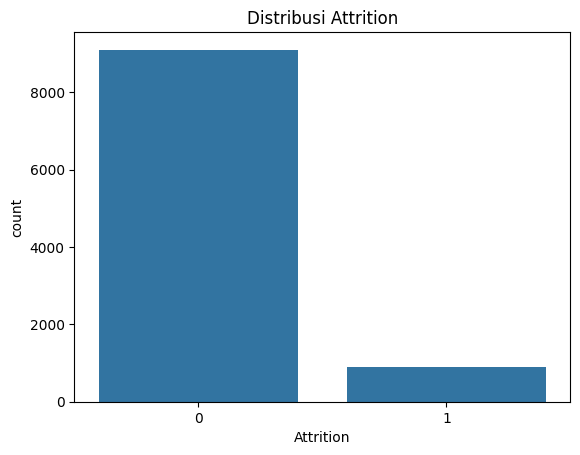

In [5]:
# ============================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

sns.countplot(x='Attrition', data=df)
plt.title("Distribusi Attrition")
plt.show()

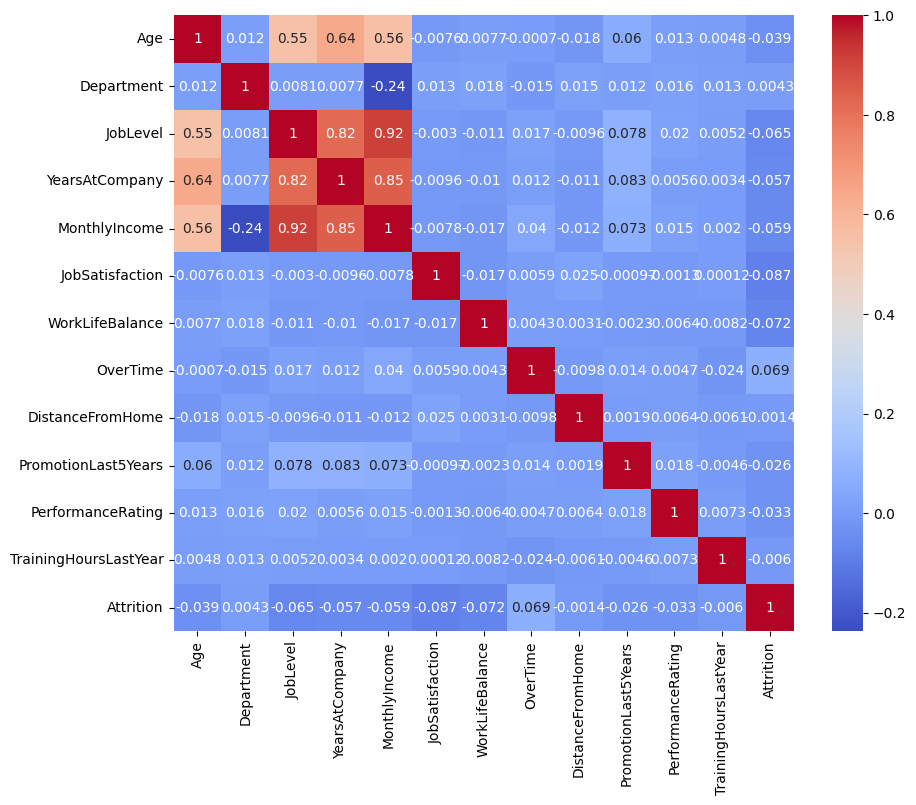

In [6]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

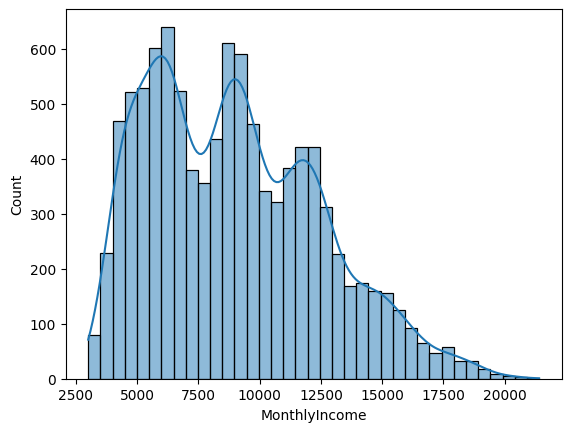

In [7]:
sns.histplot(df['MonthlyIncome'], kde=True)
plt.show()

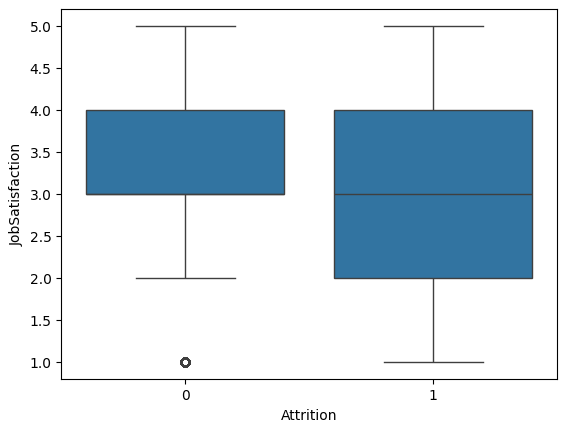

In [8]:
sns.boxplot(x='Attrition', y='JobSatisfaction', data=df)
plt.show()

In [9]:
# ============================================================
# DATA SPLITTING DAN SCALING
# ============================================================

def prepare_data(test_size):
    X = df.drop('Attrition', axis=1)
    y = df['Attrition']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    return X_train, X_test, X_train_s, X_test_s, y_train, y_test

In [10]:
# ============================================================
# MODEL BUILDING DAN HYPERPARAMETER TUNING
# ============================================================

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def run_models(test_size):
    print(f"\n===== SPLIT {int((1-test_size)*100)}:{int(test_size*100)} =====")

    X_train, X_test, X_train_s, X_test_s, y_train, y_test = prepare_data(test_size)

    # ============================================================
    # LOGISTIC REGRESSION
    # ============================================================
    log_param = {'C':[0.1, 1, 10]}
    log = GridSearchCV(LogisticRegression(max_iter=2000), log_param, cv=3)
    log.fit(X_train_s, y_train)

    y_pred = log.predict(X_test_s)
    print("\n=== Logistic Regression ===")
    print("Best Param:", log.best_params_)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # ============================================================
    # SUPPORT VECTOR MACHINE (SVM)
    # ============================================================
    svm_param = {'C':[1, 10], 'gamma':[0.01, 0.1]}
    svm = GridSearchCV(SVC(probability=True), svm_param, cv=3)
    svm.fit(X_train_s, y_train)

    y_prob = svm.predict_proba(X_test_s)[:,1]
    y_pred = (y_prob > 0.4).astype(int)

    print("\n=== Support Vector Machine (SVM) ===")
    print("Best Param:", svm.best_params_)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # ============================================================
    # GRADIENT BOOSTING
    # ============================================================
    gb_param = {'n_estimators':[100,200], 'learning_rate':[0.05,0.1]}
    gb = GridSearchCV(GradientBoostingClassifier(), gb_param, cv=3)
    gb.fit(X_train_s, y_train)

    y_prob = gb.predict_proba(X_test_s)[:,1]
    y_pred = (y_prob > 0.25).astype(int)

    print("\n=== Gradient Boosting ===")
    print("Best Param:", gb.best_params_)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

In [11]:
# ============================================================
# EKSEKUSI MODEL (DATA SPLITTING)
# ============================================================

run_models(0.3)  # 70:30
run_models(0.2)  # 80:20
run_models(0.1)  # 90:10


===== SPLIT 70:30 =====

=== Logistic Regression ===
Best Param: {'C': 0.1}
Accuracy: 0.908
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      2724
           1       0.00      0.00      0.00       276

    accuracy                           0.91      3000
   macro avg       0.45      0.50      0.48      3000
weighted avg       0.82      0.91      0.86      3000

Confusion Matrix:
[[2724    0]
 [ 276    0]]

=== Support Vector Machine (SVM) ===
Best Param: {'C': 1, 'gamma': 0.01}
Accuracy: 0.908
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      2724
           1       0.00      0.00      0.00       276

    accuracy                           0.91      3000
   macro avg       0.45      0.50      0.48      3000
weighted avg       0.82      0.91      0.86      3000

Confusion Matrix:
[[2724    0]
 [ 276    0]]

=== Gradient Boosting ===
Best Param: {'learning_rate': 0.05, 'n_estimat

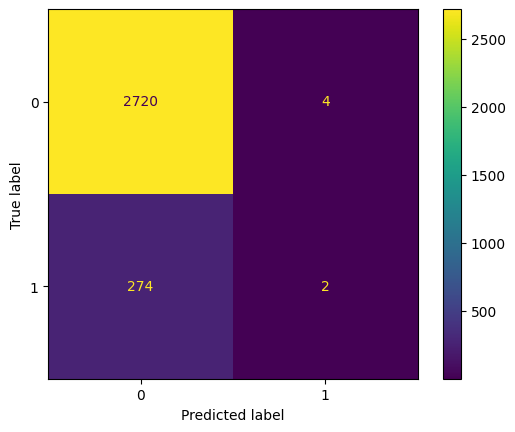

In [15]:
# ============================================================
# CONFUSION MATRIX (EVALUASI MODEL)
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

model = GradientBoostingClassifier(n_estimators=200)
X_train, X_test, _, _, y_train, y_test = prepare_data(0.3)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()